## Configs

Check if the module `torch.geometric` is installed

In [65]:
import sys
import subprocess

try:
    import torch_geometric
except ImportError:
    print("torch_geometric not found. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch_geometric"])
    print("Installation complete!")

Load modules

In [66]:
import os
from google.colab import drive

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

import torch
import torch_geometric
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

Check if the drive is mounted:

In [67]:
# Set drive path
drive_path = '/content/drive'

# Mount drive
if not os.path.exists(drive_path):
    print("Mounting Google Drive...")
    drive.mount(drive_path)
else:
    print("Google Drive is already mounted.")

Google Drive is already mounted.


Set the paths:

In [68]:
# Project path
path_root = "/content/drive/MyDrive/Deep Learning/gene_knockout/"

# Change the working directory
os.chdir(path_root)

Load my own modules:

In [69]:
from src.data_preprocessing import get_cached_dataset, prep_sklearn_data, prepare_splits, apply_gene_filter
from src.dimensionality_reduction import reduce_dimensionality_hvg
from src.plots import scatter_plot, plot_losses
from src.models_architecture import OriginalMLPRegressor, NormalizerMLPRegressor, SkipConnMLPRegressor, UltimateMLPRegressor
from src.models_training import CustomVarianceLoss, GeneDataset, train_pytorch_model
from src.models_evaluation import evaluate_baseline_model, evaluate_pytorch_model

## Data

Load the data sets

In [70]:
PC3 = get_cached_dataset(cell_line='PC3', path_root='data/')
A549 = get_cached_dataset(cell_line='A549', path_root='data/')

Define the dataset to work with:

In [71]:
dataset = PC3

## Baseline model

Let's reduce the number of relevant genes in order to simplify the calculations:

In [72]:
# Top n genes with the highest variance between the diseased and the treated states
n_base = 1000

# Get the lighter dataset and the corresponding indexes
baseline_dataset, baseline_kept_indices = reduce_dimensionality_hvg(dataset, top_k=n_base)

Train-test splitting:

In [73]:
# Generate indexes
train_idx_dict, val_idx_dict, test_idx = prepare_splits(
    dataset=baseline_dataset,
    val_size=0.1,
    test_size=0.1,
    splitting_scheme="random",
    N_folds=1,
    seed=42
)

# Split data into train and test sets
train_samples = [baseline_dataset[i] for i in train_idx_dict[0]]
val_samples = [baseline_dataset[i] for i in val_idx_dict[0]]
test_samples = [baseline_dataset[i] for i in test_idx]

Preparing data for `scikit-learn`

In [74]:
X_train, Y_train = prep_sklearn_data(train_samples)
X_test, Y_test = prep_sklearn_data(test_samples)

The most basic model is linear regression, predicting the intervened state given the diseased state and the perturbed genes.

In [75]:
# Instantiate and fit a ridge regression model
ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train, Y_train)

Ridge(alpha=1)

Baseline model's evaluation metrics:

In [76]:
# Predict results in the test set
Y_pred = ridge_model.predict(X_test)

# Compute metrics
mse, r2_scores, gene_var_scores = evaluate_baseline_model(model=ridge_model,
                        X_test=X_test,
                        Y_test= Y_test)

print("-" * 30)
print(f"Baseline Ridge MSE: {mse:.5f}")
print(f"Baseline Ridge Mean R^2 per sample: {np.mean(r2_scores):.5f} +/- {np.std(r2_scores):.5f}")
print(f"Baseline Ridge Mean Gene Var Score: {np.mean(gene_var_scores):.5f} +/- {np.std(gene_var_scores):.5f}")
print("-" * 30)

------------------------------
Baseline Ridge MSE: 0.06545
Baseline Ridge Mean R^2 per sample: 0.79879 +/- 0.00000
Baseline Ridge Mean Gene Var Score: 0.09564 +/- 0.00000
------------------------------


Evaluating the std deviation per gene (predicted vs real):

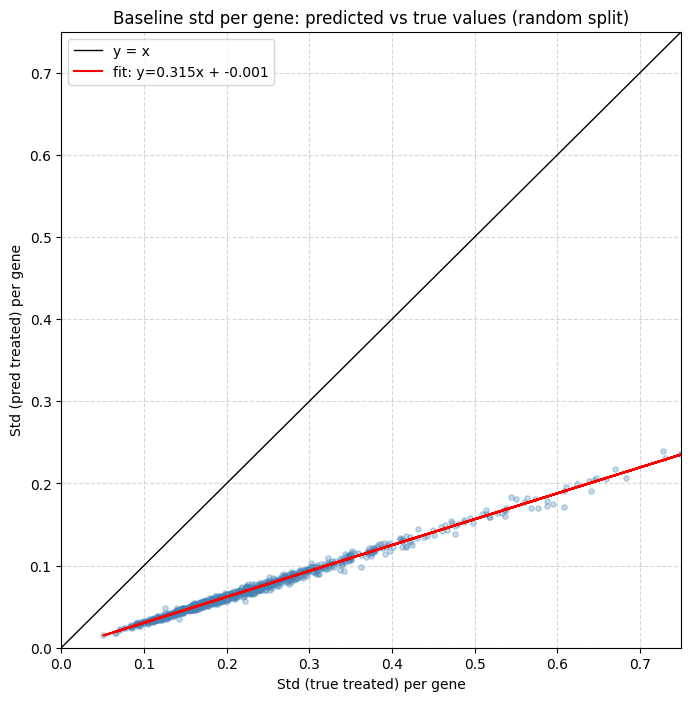

In [77]:
# Compute standard deviation
std_true = np.std(Y_test, axis=0)
std_pred = np.std(Y_pred, axis=0)

# Scatter plot
scatter_plot(x=std_true, y=std_pred,
            title="Baseline std per gene: predicted vs true values (random split)",
            xlabel="Std (true treated) per gene",
            ylabel="Std (pred treated) per gene")

## MLP

Dimensionality reduction:

In [78]:
# Top n genes with the highest variance between the diseased and the treated states
n = 3000

# Get the lighter datasets and the corresponding indexes
reduced_dataset, kept_indices = reduce_dimensionality_hvg(dataset, top_k=n)

### Data preprocessing

In [93]:
# Generate indices
train_idx_dict, val_idx_dict, test_idx = prepare_splits(
    dataset=dataset,
    val_size=0.1,
    test_size=0.1,
    splitting_scheme="random",
    N_folds=1,
    seed=42
)

# Split data into train and test sets
train_samples = [reduced_dataset[i] for i in train_idx_dict[0]]
val_samples = [reduced_dataset[i] for i in val_idx_dict[0]]
test_samples = [reduced_dataset[i] for i in test_idx]

# DataLoaders configuration
batch_size = 64
train_loader = DataLoader(GeneDataset(train_samples),
                        batch_size=batch_size, shuffle=True)
val_loader = DataLoader(GeneDataset(val_samples),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(GeneDataset(test_samples),
                        batch_size=batch_size, shuffle=False)

### Train phase

In [94]:
# --- Training configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training in: {device}")

n_epochs = 150

model = UltimateMLPRegressor(d=n).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# --- Training loop ---
skipconn_MLP, losses = train_pytorch_model(model=model,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    criterion=criterion,
                    optimizer=optimizer,
                    device=device,
                    epochs=n_epochs)

Training in: cuda
Starting training on cuda...
Epoch 01/150 | Train Loss: 0.2629 | Val Loss: 0.1343
Epoch 02/150 | Train Loss: 0.1668 | Val Loss: 0.0956
Epoch 03/150 | Train Loss: 0.1406 | Val Loss: 0.0861
Epoch 04/150 | Train Loss: 0.1298 | Val Loss: 0.0820
Epoch 05/150 | Train Loss: 0.1230 | Val Loss: 0.0792
Epoch 06/150 | Train Loss: 0.1181 | Val Loss: 0.0774
Epoch 07/150 | Train Loss: 0.1141 | Val Loss: 0.0763
Epoch 08/150 | Train Loss: 0.1106 | Val Loss: 0.0757
Epoch 09/150 | Train Loss: 0.1076 | Val Loss: 0.0748
Epoch 10/150 | Train Loss: 0.1049 | Val Loss: 0.0738
Epoch 11/150 | Train Loss: 0.1017 | Val Loss: 0.0729
Epoch 12/150 | Train Loss: 0.0992 | Val Loss: 0.0726
Epoch 13/150 | Train Loss: 0.0969 | Val Loss: 0.0719
Epoch 14/150 | Train Loss: 0.0946 | Val Loss: 0.0709
Epoch 15/150 | Train Loss: 0.0923 | Val Loss: 0.0705
Epoch 16/150 | Train Loss: 0.0898 | Val Loss: 0.0704
Epoch 17/150 | Train Loss: 0.0874 | Val Loss: 0.0731
Epoch 18/150 | Train Loss: 0.0854 | Val Loss: 0.0692

### Evaluation phase

Train vs test loss:

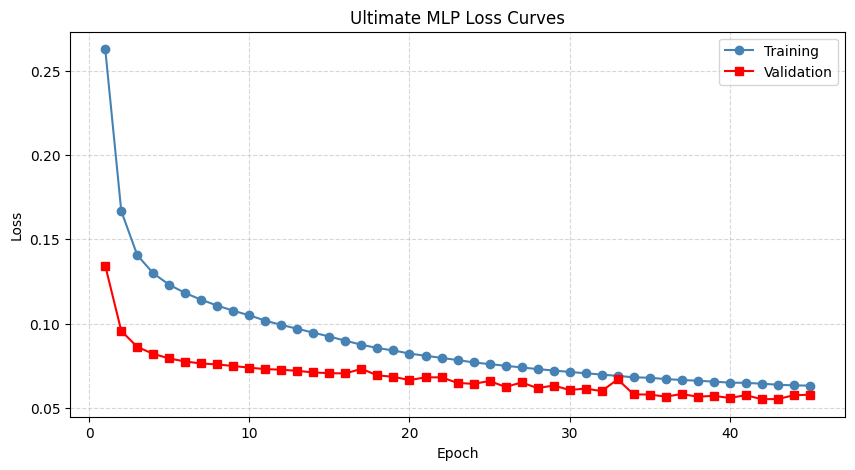

In [95]:
plot_losses(losses=losses,
            title="Ultimate MLP Loss Curves",
            xlabel="Epoch", ylabel="Loss")

Compute metrics:

In [96]:
# Compute metrics
mse, r2_scores, gene_var_scores, Y_true_dl, Y_pred_dl = evaluate_pytorch_model(model=model,
                    test_loader=test_loader,
                    device=device)

# Display results
print("-" * 30)
print(f"Ultimate MLP MSE: {mse:.5f}")
print(f"Ultimate MLP Mean R^2 per sample: {np.mean(r2_scores):.5f} +/- {np.std(r2_scores):.5f}")
print(f"Ultimate MLP Mean Gene Var Score: {np.mean(gene_var_scores):.5f} +/- {np.std(gene_var_scores):.5f}")
print("-" * 30)

------------------------------
Ultimate MLP MSE: 0.05510
Ultimate MLP Mean R^2 per sample: 0.76967 +/- 0.00000
Ultimate MLP Mean Gene Var Score: 0.69681 +/- 0.00000
------------------------------


Per gene std scatter plot:

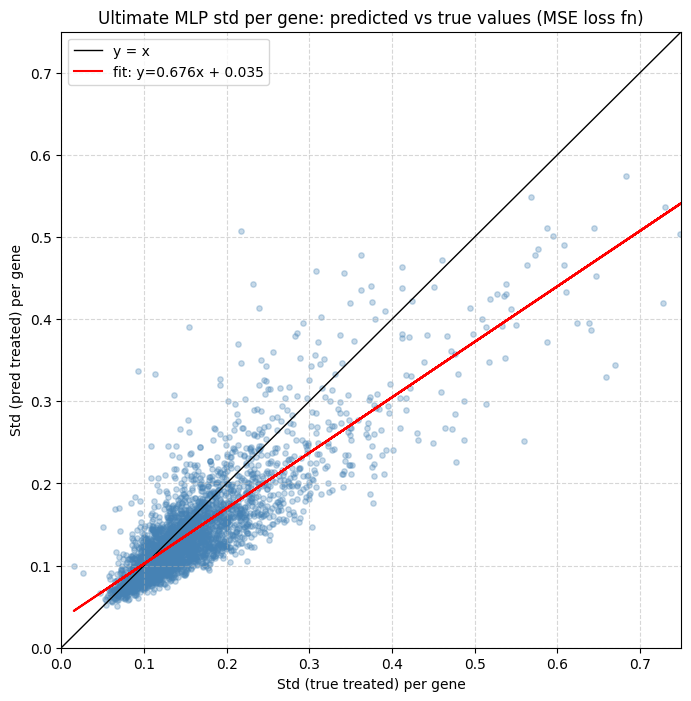

In [97]:
# Compute standard deviation
std_true = np.std(Y_true_dl, axis=0)
std_pred_dl = np.std(Y_pred_dl, axis=0)

# Display scatter plot
scatter_plot(x=std_true, y=std_pred_dl,
                    title="Ultimate MLP std per gene: predicted vs true values (MSE loss fn)",
                    xlabel="Std (true treated) per gene",
                    ylabel="Std (pred treated) per gene")

## Final model

Now that we have the optimal model, let's train it using the A549 line cell and test it using the PC3 line cell.

In [107]:
# Concatenate HT29 and A549 cell lines lists
dataset_train = PC3

Now, let's reduce dimensionality:

In [108]:
# Select top genes with the highest variance in the training set
n_final = 3000
train_dataset_reduced, kept_indices_final = reduce_dimensionality_hvg(dataset_train, top_k=n_final)

# Apply the exact same gene filter to the test set
test_dataset_reduced = apply_gene_filter(A549, kept_indices_final)


Now we need a validation set to asess the early stopping during the model's training:

In [109]:
# Generate indices
train_samples, val_samples = train_test_split(
    train_dataset_reduced,
    test_size=0.1,
    random_state=42
)

test_samples = test_dataset_reduced

# Create data loaders
batch_size = 64
train_loader = DataLoader(GeneDataset(train_samples), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(GeneDataset(val_samples), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(GeneDataset(test_samples), batch_size=batch_size, shuffle=False)

Now let's train the model:

In [110]:
# --- Training configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training in: {device}")
model_cross = UltimateMLPRegressor(d=n_final).to(device)

criterion = CustomVarianceLoss()
optimizer = optim.Adam(model_cross.parameters(), lr=1e-5)

# Entrenamos
trained_model_cross, history_cross = train_pytorch_model(
    model=model_cross,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=150,
    patience=3
)

Training in: cuda
Starting training on cuda...
Epoch 01/150 | Train Loss: 1.7802 | Val Loss: 0.3742
Epoch 02/150 | Train Loss: 0.7630 | Val Loss: 0.2213
Epoch 03/150 | Train Loss: 0.5257 | Val Loss: 0.1732
Epoch 04/150 | Train Loss: 0.4220 | Val Loss: 0.1539
Epoch 05/150 | Train Loss: 0.3630 | Val Loss: 0.1433
Epoch 06/150 | Train Loss: 0.3235 | Val Loss: 0.1366
Epoch 07/150 | Train Loss: 0.2941 | Val Loss: 0.1314
Epoch 08/150 | Train Loss: 0.2714 | Val Loss: 0.1278
Epoch 09/150 | Train Loss: 0.2520 | Val Loss: 0.1251
Epoch 10/150 | Train Loss: 0.2351 | Val Loss: 0.1215
Epoch 11/150 | Train Loss: 0.2193 | Val Loss: 0.1186
Epoch 12/150 | Train Loss: 0.2057 | Val Loss: 0.1166
Epoch 13/150 | Train Loss: 0.1935 | Val Loss: 0.1141
Epoch 14/150 | Train Loss: 0.1815 | Val Loss: 0.1111
Epoch 15/150 | Train Loss: 0.1729 | Val Loss: 0.1095
Epoch 16/150 | Train Loss: 0.1644 | Val Loss: 0.1065
Epoch 17/150 | Train Loss: 0.1560 | Val Loss: 0.1059
Epoch 18/150 | Train Loss: 0.1490 | Val Loss: 0.1031

Train vs test loss:

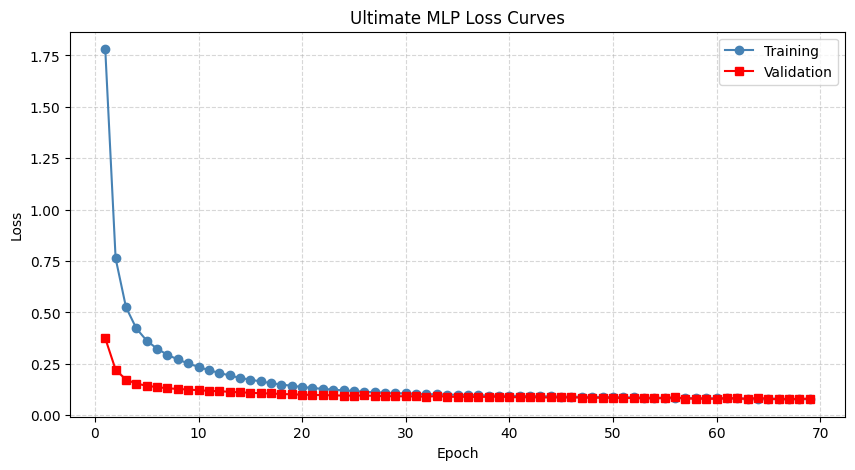

In [111]:
plot_losses(losses=history_cross,
            title="Ultimate MLP Loss Curves",
            xlabel="Epoch", ylabel="Loss")

Evaluate the model:

In [112]:
# Compute metrics
mse, r2_scores, gene_var_scores, Y_true_cross, Y_pred_cross = evaluate_pytorch_model(model=model_cross,
                    test_loader=test_loader,
                    device=device)

# Display results
print("-" * 30)
print(f"Ultimate MLP MSE: {mse:.5f}")
print(f"Ultimate MLP Mean R^2 per sample: {np.mean(r2_scores):.5f}")
print(f"Ultimate MLP Mean Gene Var Score: {np.mean(gene_var_scores):.5f}")
print("-" * 30)

------------------------------
Ultimate MLP MSE: 0.08451
Ultimate MLP Mean R^2 per sample: 0.69341
Ultimate MLP Mean Gene Var Score: 0.74353
------------------------------


Per gene std scatter plot:

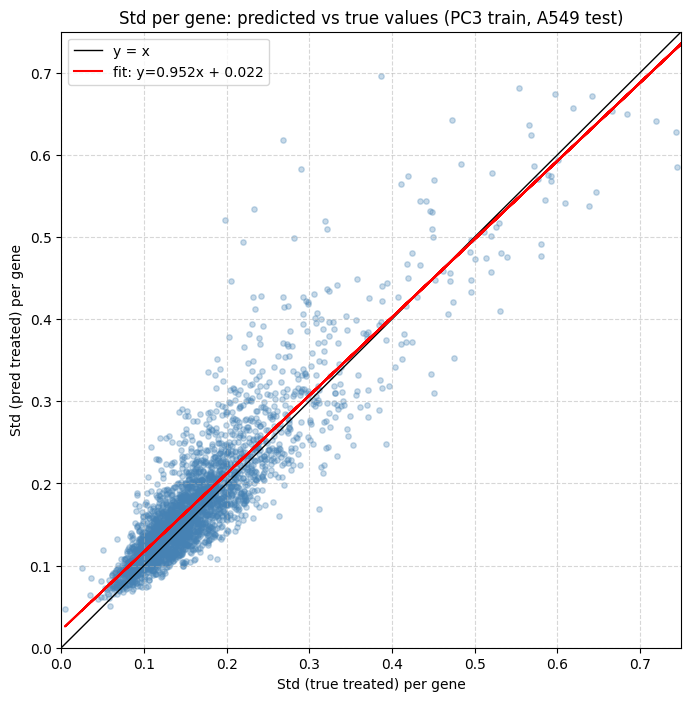

In [113]:
# Compute standard deviation
std_true = np.std(Y_true_cross, axis=0)
std_pred_cross = np.std(Y_pred_cross, axis=0)

# Display scatter plot
scatter_plot(x=std_true, y=std_pred_cross,
                    title="Std per gene: predicted vs true values (PC3 train, A549 test)",
                    xlabel="Std (true treated) per gene",
                    ylabel="Std (pred treated) per gene")

## Conclusion

Even though the metrics aren't that good (the MSE is slightly higher in the model that crosses both cell lines and the R-squared is slightly lower), the ultimate model preserves the variance between the diseased and the intervened state.